In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv('Travel details dataset.csv')

df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID               139 non-null    int64  
 1   Destination           137 non-null    str    
 2   Start date            137 non-null    str    
 3   End date              137 non-null    str    
 4   Duration (days)       137 non-null    float64
 5   Traveler name         137 non-null    str    
 6   Traveler age          137 non-null    float64
 7   Traveler gender       137 non-null    str    
 8   Traveler nationality  137 non-null    str    
 9   Accommodation type    137 non-null    str    
 10  Accommodation cost    137 non-null    str    
 11  Transportation type   136 non-null    str    
 12  Transportation cost   136 non-null    str    
dtypes: float64(2), int64(1), str(10)
memory usage: 14.2 KB


,Trip ID,Duration (days),Traveler age
count,139.000000,137.000000,137.000000
mean,70.000000,7.605839,33.175182
std,40.269923,1.601276,7.145441
min,1.000000,5.000000,20.000000
25%,35.500000,7.000000,28.000000
50%,70.000000,7.000000,31.000000
75%,104.500000,8.000000,38.000000
max,139.000000,14.000000,60.000000


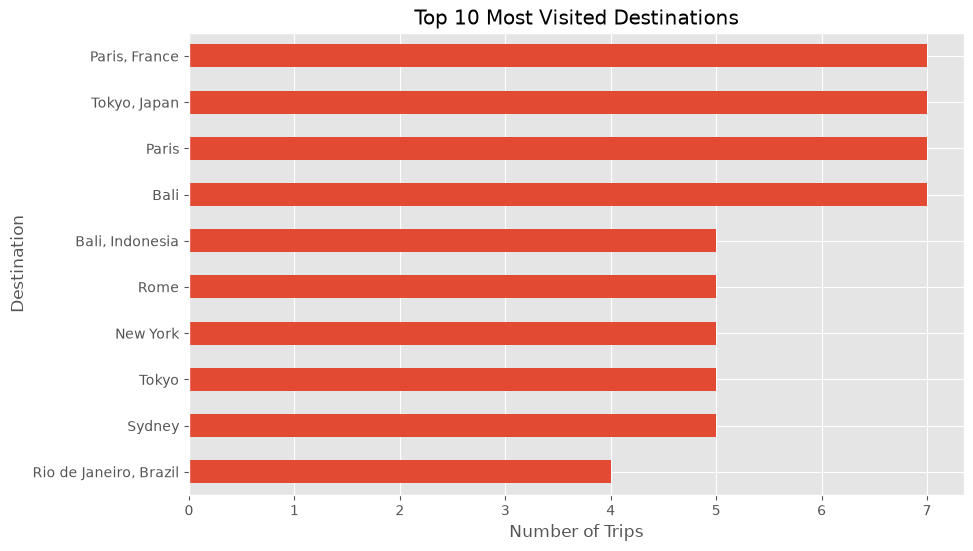

In [7]:
destination_counts = df['Destination'].value_counts().head(10)

plt.figure(figsize=(10, 6))
destination_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Most Visited Destinations')
plt.xlabel('Number of Trips')
plt.ylabel('Destination')

plt.show()

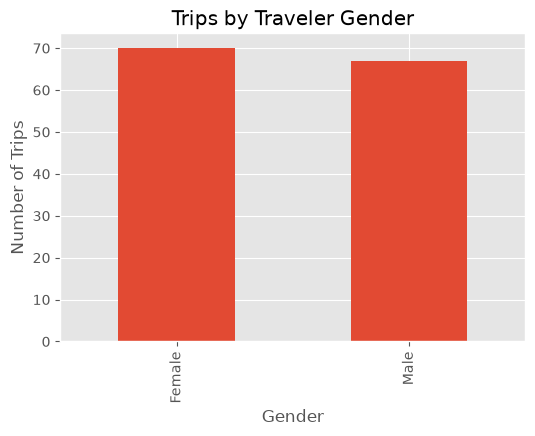

In [8]:
gender_counts = df['Traveler gender'].value_counts()

plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar')

plt.title('Trips by Traveler Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')

plt.show()

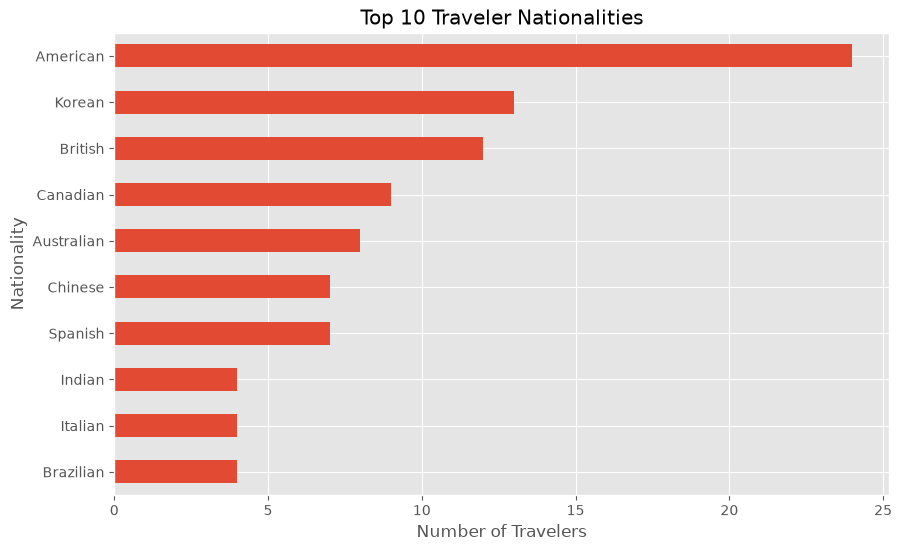

In [9]:
nationality_counts = df['Traveler nationality'].value_counts().head(10)

plt.figure(figsize=(10, 6))
nationality_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Traveler Nationalities')
plt.xlabel('Number of Travelers')
plt.ylabel('Nationality')

plt.show()

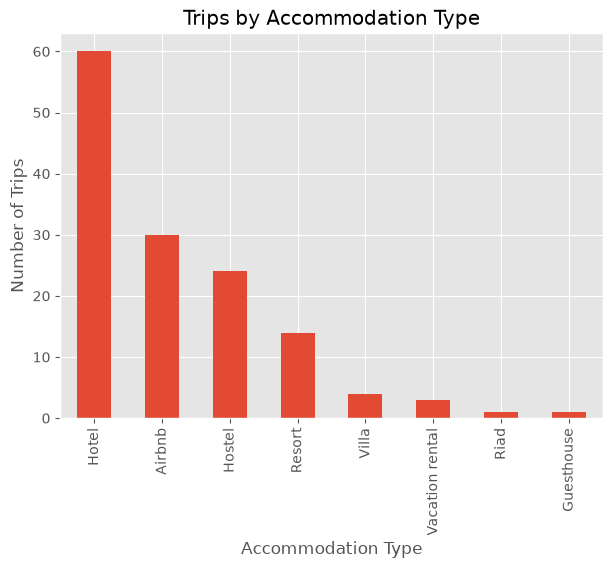

In [10]:
accommodation_counts = df['Accommodation type'].value_counts()

plt.figure(figsize=(7, 5))
accommodation_counts.plot(kind='bar')

plt.title('Trips by Accommodation Type')
plt.xlabel('Accommodation Type')
plt.ylabel('Number of Trips')

plt.show()

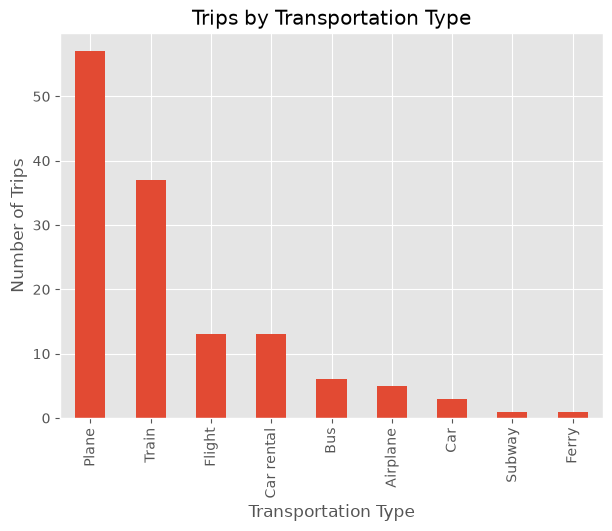

In [11]:
transport_counts = df['Transportation type'].value_counts()

plt.figure(figsize=(7, 5))
transport_counts.plot(kind='bar')

plt.title('Trips by Transportation Type')
plt.xlabel('Transportation Type')
plt.ylabel('Number of Trips')

plt.show()

In [12]:
df['Accommodation cost'] = pd.to_numeric(
    df['Accommodation cost'], 
    errors='coerce'
)

df['Transportation cost'] = pd.to_numeric(
    df['Transportation cost'], 
    errors='coerce'
)

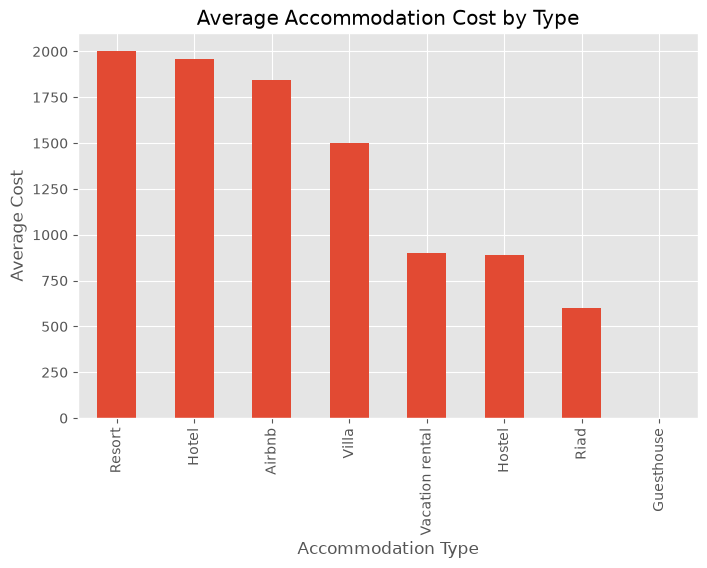

In [13]:
accommodation_cost = (
    df.groupby('Accommodation type')['Accommodation cost']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
accommodation_cost.plot(kind='bar')

plt.title('Average Accommodation Cost by Type')
plt.xlabel('Accommodation Type')
plt.ylabel('Average Cost')

plt.show()

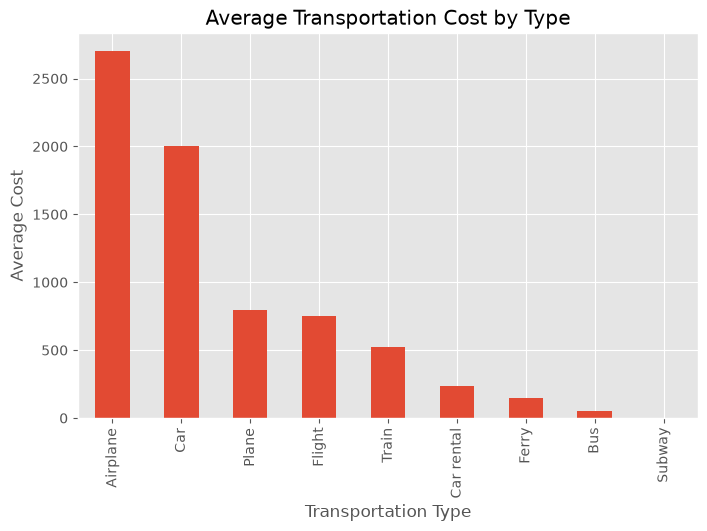

In [14]:
transport_cost = (
    df.groupby('Transportation type')['Transportation cost']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
transport_cost.plot(kind='bar')

plt.title('Average Transportation Cost by Type')
plt.xlabel('Transportation Type')
plt.ylabel('Average Cost')

plt.show()

In [15]:
df['Total Trip Cost'] = (
    df['Accommodation cost'] +
    df['Transportation cost']
)

df[['Trip ID', 'Destination', 'Total Trip Cost']].head()

,Trip ID,Destination,Total Trip Cost
0,1,"London, UK",1800.0
1,2,"Phuket, Thailand",1300.0
2,3,"Bali, Indonesia",1700.0
3,4,"New York, USA",3000.0
4,5,"Tokyo, Japan",900.0


<Figure size 1000x600 with 0 Axes>

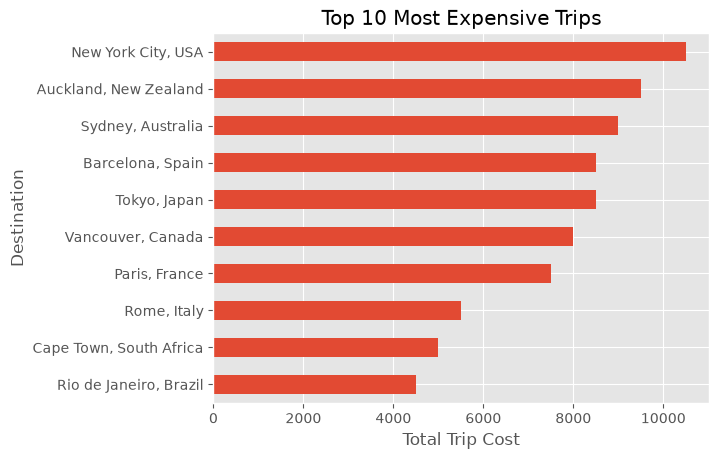

In [16]:
top10_expensive = (
    df[['Destination', 'Total Trip Cost']]
    .sort_values('Total Trip Cost', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top10_expensive.sort_values('Total Trip Cost').plot(
    x='Destination',
    y='Total Trip Cost',
    kind='barh',
    legend=False
)

plt.title('Top 10 Most Expensive Trips')
plt.xlabel('Total Trip Cost')
plt.ylabel('Destination')

plt.show()

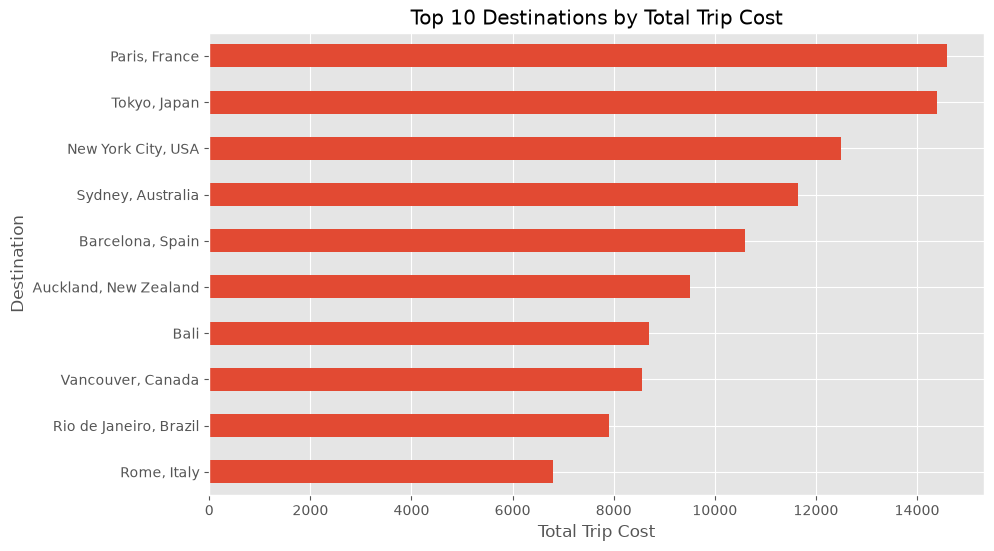

In [17]:
destination_cost = (
    df.groupby('Destination')['Total Trip Cost']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

destination_cost.sort_values().plot(kind='barh')

plt.title('Top 10 Destinations by Total Trip Cost')
plt.xlabel('Total Trip Cost')
plt.ylabel('Destination')

plt.show()

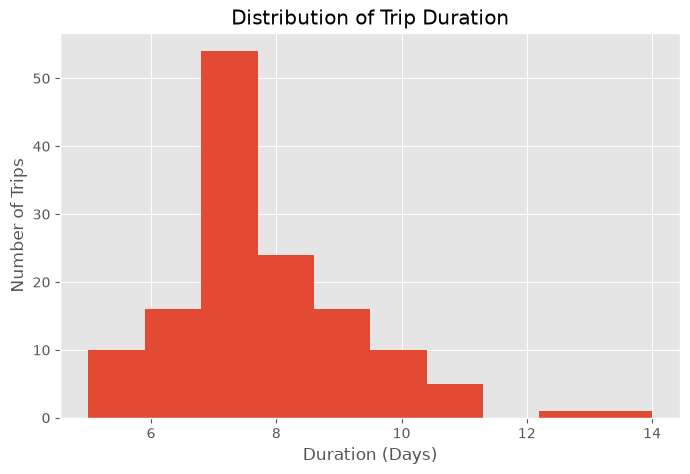

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['Duration (days)'].dropna(),
    bins=10
)

plt.title('Distribution of Trip Duration')
plt.xlabel('Duration (Days)')
plt.ylabel('Number of Trips')

plt.show()

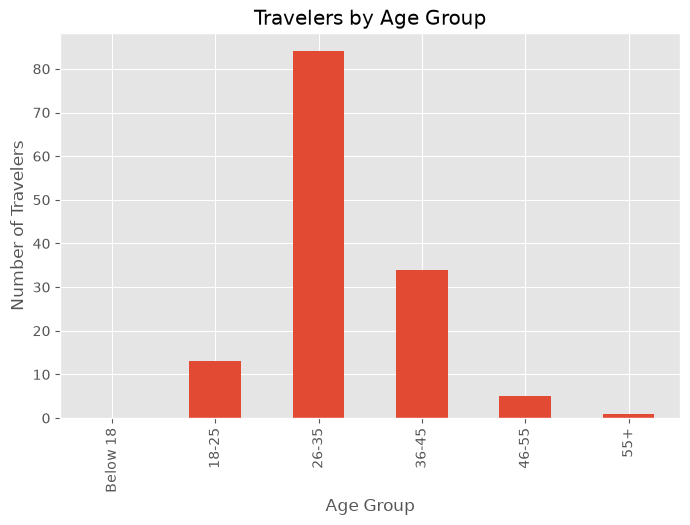

In [19]:
bins = [0, 18, 25, 35, 45, 55, 100]

labels = [
    'Below 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '55+'
]

df['Age Group'] = pd.cut(
    df['Traveler age'],
    bins=bins,
    labels=labels
)

age_group = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

age_group.plot(kind='bar')

plt.title('Travelers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Travelers')

plt.show()

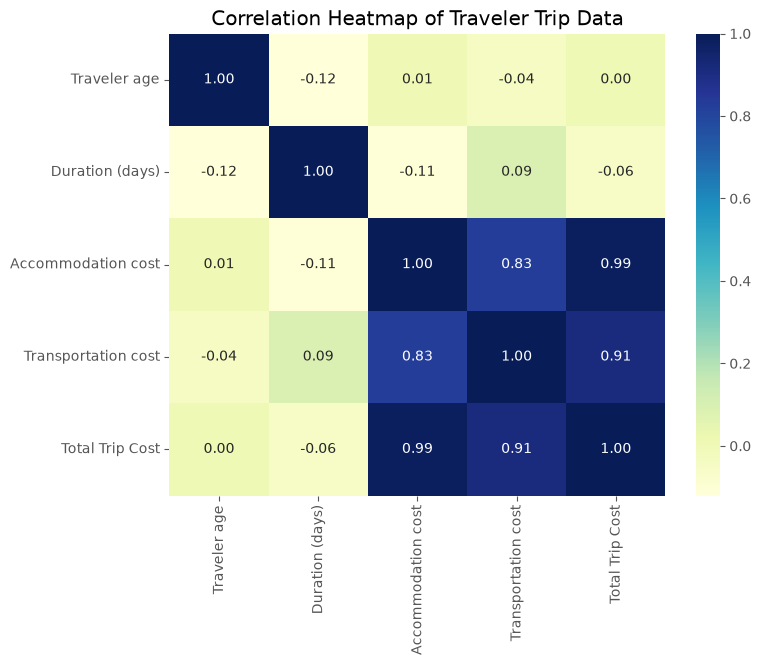

In [20]:
numeric_data = df[
    [
        'Traveler age',
        'Duration (days)',
        'Accommodation cost',
        'Transportation cost',
        'Total Trip Cost'
    ]
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Correlation Heatmap of Traveler Trip Data')

plt.show()